# ¿Cuánto vale tu trabajo? Salario Mínimo y Desigualdad en la Unión Europea

> *"En 2006, una semana de sueldo pagaba el alquiler del mes. En 2025, no alcanza ni para la mitad."*

---
## 1. DESCRIPCIÓN DEL PROYECTO

Este proyecto analiza la evolución del **salario mínimo en los países de la Unión Europea** desde una perspectiva que va más allá del número en euros: lo que realmente puedes comprar con él, cuánto te queda después de pagar el alquiler, si protege a las mujeres de la desigualdad salarial, y si de verdad tener trabajo te salva de la pobreza.

El punto de partida es una pregunta muy concreta y muy actual: **¿sirve de algo el salario mínimo en Europa hoy?**

La motivación no es solo académica. El 23 de marzo de 2026 hay huelga general en Euskadi para exigir un salario mínimo de 1.500€. Este análisis intenta responder con datos si esa reivindicación tiene base, y cómo se compara con el resto de Europa.

---
## 2. HIPÓTESIS

Estas son las cinco hipótesis que guían el análisis. Están planteadas **antes de ver los datos** — eso es fundamental en un EDA riguroso. Al final del proyecto comprobaremos cuáles se confirman y cuáles no.

---

**H1 — El salario mínimo nominal engaña** *(hipótesis principal)*  
Los países con mayor salario mínimo en euros no son necesariamente los que ofrecen mayor poder adquisitivo real. Al ajustar por el coste de vida mediante PPS (Purchasing Power Standard), las diferencias entre países se reducen drásticamente.

---

**H2 — Subir el salario mínimo es política de igualdad de género, aunque nadie lo llame así**  
Los países con un salario mínimo más alto como porcentaje del salario medio tienen una brecha salarial de género menor. Las mujeres están sobrerrepresentadas en los empleos peor pagados, por lo que subir el suelo salarial las beneficia desproporcionadamente.

---

**H3 — En la mayoría de la UE, cobrar el mínimo significa no poder pagar el alquiler**  
El salario mínimo no es suficiente para vivir de forma independiente en la mayoría de países europeos: destinar más del 40% del sueldo al alquiler hace imposible la emancipación para millones de jóvenes europeos.

---

**H4 — Working poor: tener trabajo no te salva de la pobreza**  
Los países con un salario mínimo más bajo en términos reales concentran una mayor proporción de trabajadores en riesgo de exclusión social. Tener empleo no garantiza no ser pobre.

---

**H5 — La Generación Z es la primera que trabaja más para vivir peor que sus padres**  
Los salarios mínimos han subido en casi todos los países de la UE, pero la combinación de alquileres disparados y estancamiento salarial hace que la generación Z tenga peor capacidad adquisitiva real que sus padres a la misma edad.

---
## 3. FUENTES DE DATOS

Todos los datos provienen de fuentes oficiales europeas, lo que garantiza su fiabilidad y comparabilidad entre países.

| Dataset | Fuente | Código | Descripción |
|---|---|---|---|
| Salario mínimo mensual | Eurostat | `earn_mw_cur` | Salario mínimo bruto en euros, por país y semestre |
| PIB per cápita en PPS | Eurostat | `tec00114` | Riqueza del país ajustada por poder adquisitivo |
| Índice de precios de vivienda | Eurostat | `prc_hpi_a` | Evolución de precios de alquiler y compra |
| Brecha salarial de género | Eurostat | `sdg_05_20` | Diferencia % en salario bruto hora entre hombres y mujeres |
| Trabajadores en riesgo de pobreza | Eurostat | `tespm070` | % de trabajadores activos en riesgo de pobreza |

**¿Qué es Eurostat?** Es la oficina estadística oficial de la Unión Europea. Recopila datos de los 27 países miembros y los publica de forma estandarizada para que sean comparables entre países. Es la fuente más fiable para análisis económicos europeos.

**¿Qué es PPS?** Purchasing Power Standard (Estándar de Poder Adquisitivo). Es una moneda artificial que permite comparar lo que realmente puedes comprar en cada país, eliminando las diferencias de precios. 1.000€ en Luxemburgo compran menos que 1.000€ en Bulgaria.

---
## 4. CARGA DE DATOS

### 4.1 Importación de librerías

Antes de cargar cualquier dato, importamos las librerías que vamos a necesitar. Una **librería** es un conjunto de herramientas ya programadas que alguien ha creado para que no tengamos que escribir todo desde cero.

In [2]:
# pandas: la librería principal para trabajar con tablas de datos (DataFrames)
import pandas as pd

# numpy: librería para operaciones matemáticas con arrays
import numpy as np

# matplotlib y seaborn: para crear gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# requests: para hacer peticiones a APIs (descargar datos de internet desde Python)
import requests

# Configuración visual de las gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Para que no salgan warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


### 4.2 Carga del dataset principal — Salario Mínimo

Cargamos el archivo que descargamos de Eurostat. Este archivo tiene formato TSV (Tab Separated Values) — es igual que un CSV pero los valores están separados por tabulaciones en vez de comas. Pandas lo lee exactamente igual, solo cambiamos el separador.

In [5]:
# pd.read_csv() puede leer tanto CSV como TSV
# sep='\t' le dice que el separador es una tabulación (\t)
# Fuente: Eurostat, dataset earn_mw_cur
# URL: https://ec.europa.eu/eurostat/databrowser/view/earn_mw_cur/default/table

fuente_1 = 'Eurostat - Monthly minimum wages (earn_mw_cur)'
df_salario = pd.read_csv('./data/salario_minimo.tsv', sep='\t')

print(f'Dataset cargado: {df_salario.shape[0]} filas x {df_salario.shape[1]} columnas')
df_salario.head(10)

Dataset cargado: 38 filas x 11 columnas


,"freq,currency,geo\TIME_PERIOD",2021-S2,2022-S1,2022-S2,2023-S1,2023-S2,2024-S1,2024-S2,2025-S1,2025-S2,2026-S1
0,"S,EUR,AL",245,248,269,298,376,385,399,408,408,517
1,"S,EUR,AT",: m,: m,: m,: m,: m,: m,: m,: m,: m,: m
2,"S,EUR,BE",1626,1658,1842,1955,1955,1994,2070,2070,2112,2112
3,"S,EUR,BG",332,332,363,399,399,477,477,551,551,620
4,"S,EUR,CH",: m,: m,: m,: m,: m,: m,: m,: m,: m,: m
5,"S,EUR,CY",: m,: m,: m,940,940,1000,1000,1000,1000,1088
6,"S,EUR,CZ",596,652,655,717,729,764,755,826,841,924
7,"S,EUR,DE",1602,1634,1739,1997,1997,2054,2054,2161,2161,2343
8,"S,EUR,DK",: m,: m,: m,: m,: m,: m,: m,: m,: m,: m
9,"S,EUR,EE",584,654,654,725,725,820,820,886,886,886


### 4.3 Descarga del histórico completo via API de Eurostat

El archivo descargado solo tiene 10 períodos de tiempo. Para tener el histórico completo (desde 1999), usamos la **API de Eurostat** — una forma de pedir datos directamente desde Python sin pasar por la web.

**¿Qué es una API?** Application Programming Interface. Es como un "camarero" entre tu código y una base de datos: tú le dices qué quieres, él va a buscarlo y te lo trae. En este caso le pedimos los datos de salario mínimo directamente a Eurostat.

In [6]:
# URL de la API de Eurostat para el dataset de salario mínimo
# format=JSON le pide los datos en formato JSON (otro formato de datos muy común)
url_api = 'https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/earn_mw_cur?format=JSON&lang=EN&freq=S&currency=EUR'

# requests.get() hace la petición a la URL, como si escribieras la dirección en el navegador
respuesta = requests.get(url_api)

# Comprobamos que la petición ha funcionado
# El código 200 significa 'éxito'. El 404 es el famoso 'página no encontrada'
print(f'Código de respuesta: {respuesta.status_code}')

if respuesta.status_code == 200:
    print('✅ Conexión con la API de Eurostat exitosa')
else:
    print('❌ Error de conexión. Usaremos el archivo local descargado.')

Código de respuesta: 200
✅ Conexión con la API de Eurostat exitosa


In [7]:
# Convertimos la respuesta JSON en un diccionario de Python
datos_json = respuesta.json()

# El JSON de Eurostat tiene una estructura específica:
# - 'dimension': contiene los índices (países, tiempo)
# - 'value': contiene los valores numéricos
# Extraemos los países y los períodos de tiempo
paises = datos_json['dimension']['geo']['category']['label']      # diccionario código->nombre
tiempos = datos_json['dimension']['time']['category']['label']    # diccionario código->período
valores = datos_json['value']                                      # diccionario índice->valor

print(f'Países disponibles: {len(paises)}')
print(f'Períodos de tiempo disponibles: {len(tiempos)}')
print(f'Valores totales: {len(valores)}')

Países disponibles: 39
Períodos de tiempo disponibles: 55
Valores totales: 1531


In [8]:
# Construimos el DataFrame a partir de los datos del JSON
# Esto es lo que se llama 'parsear' un JSON: extraer los datos y organizarlos

lista_paises = list(paises.values())   # ['Albania', 'Austria', 'Belgium', ...]
lista_tiempos = list(tiempos.values()) # ['1999-S1', '1999-S2', '2000-S1', ...]

n_paises = len(lista_paises)
n_tiempos = len(lista_tiempos)

# Creamos una matriz vacía (filas=países, columnas=tiempo)
# np.nan significa 'valor vacío' - lo usamos cuando no hay dato
matriz = np.full((n_paises, n_tiempos), np.nan)

# Rellenamos la matriz con los valores del JSON
# El JSON codifica la posición de cada valor como un índice numérico
for idx_str, valor in valores.items():
    idx = int(idx_str)
    fila = idx // n_tiempos   # división entera: qué país
    col = idx % n_tiempos     # resto: qué período
    matriz[fila][col] = valor

# Creamos el DataFrame con nombres de filas y columnas
df_salario_historico = pd.DataFrame(
    matriz,
    index=lista_paises,
    columns=lista_tiempos
)

print(f'DataFrame creado: {df_salario_historico.shape[0]} países x {df_salario_historico.shape[1]} períodos')
df_salario_historico.head()

DataFrame creado: 39 países x 55 períodos


,1999-S1,1999-S2,2000-S1,2000-S2,2001-S1,2001-S2,2002-S1,2002-S2,2003-S1,2003-S2,...,2021-S2,2022-S1,2022-S2,2023-S1,2023-S2,2024-S1,2024-S2,2025-S1,2025-S2,2026-S1
Belgium,1074.0,1096.0,1096.0,1096.0,1118.0,1140.0,1140.0,1163.0,1163.0,1186.0,...,1626.0,1658.0,1842.0,1955.0,1955.0,1994.0,2070.0,2070.0,2112.0,2112.0
Bulgaria,31.0,34.0,34.0,38.0,40.0,43.0,51.0,51.0,56.0,56.0,...,332.0,332.0,363.0,399.0,399.0,477.0,477.0,551.0,551.0,620.0
Czechia,92.0,99.0,111.0,126.0,143.0,148.0,178.0,195.0,196.0,196.0,...,596.0,652.0,655.0,717.0,729.0,764.0,755.0,826.0,841.0,924.0
Denmark,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1602.0,1634.0,1739.0,1997.0,1997.0,2054.0,2054.0,2161.0,2161.0,2343.0


### 4.4 Transformación a formato 'long'

Ahora mismo el DataFrame está en formato **'wide'** (ancho): cada columna es un período de tiempo. Para analizar mejor los datos, lo convertimos a formato **'long'** (largo): cada fila es una combinación país-año.

Esto es muy importante en data science. El formato long es el estándar para análisis y visualizaciones porque cada fila es una observación.

In [9]:
# reset_index() convierte el índice (países) en una columna normal
df_long = df_salario_historico.reset_index()
df_long = df_long.rename(columns={'index': 'pais'})

# pd.melt() transforma de formato wide a long
# id_vars: columnas que se quedan fijas (el país)
# var_name: nombre para la columna que antes eran los headers (el tiempo)
# value_name: nombre para la columna de valores (el salario)
df_long = pd.melt(
    df_long,
    id_vars='pais',
    var_name='periodo',
    value_name='salario_minimo_eur'
)

# Extraemos el año del período (de '2020-S1' sacamos 2020)
df_long['anio'] = df_long['periodo'].str[:4].astype(int)

# Extraemos el semestre (S1 o S2)
df_long['semestre'] = df_long['periodo'].str[5:]

# Eliminamos filas sin dato (países sin salario mínimo como Dinamarca)
df_long = df_long.dropna(subset=['salario_minimo_eur'])

# Ordenamos por país y año
df_long = df_long.sort_values(['pais', 'anio', 'semestre']).reset_index(drop=True)

print(f'Dataset en formato long: {df_long.shape[0]} filas x {df_long.shape[1]} columnas')
print(f'Países con datos: {df_long["pais"].nunique()}')
print(f'Rango de años: {df_long["anio"].min()} - {df_long["anio"].max()}')
df_long.head(10)

Dataset en formato long: 1531 filas x 5 columnas
Países con datos: 31
Rango de años: 1999 - 2026


,pais,periodo,salario_minimo_eur,anio,semestre
0,Albania,1999-S2,45.0,1999,S2
1,Albania,2000-S1,47.0,2000,S1
2,Albania,2000-S2,52.0,2000,S2
3,Albania,2001-S1,53.0,2001,S1
4,Albania,2001-S2,60.0,2001,S2
5,Albania,2002-S1,63.0,2002,S1
6,Albania,2002-S2,68.0,2002,S2
7,Albania,2003-S1,67.0,2003,S1
8,Albania,2003-S2,74.0,2003,S2
9,Albania,2004-S1,75.0,2004,S1


### 4.5 Vista general del dataset principal

In [10]:
# .info() nos da un resumen: tipos de datos, valores no nulos por columna
# Es lo primero que hace cualquier data scientist cuando ve un dataset nuevo
print('=== INFORMACIÓN GENERAL ===')
df_long.info()
print()

# .describe() nos da estadísticos básicos de las columnas numéricas
# mean=media, std=desviación estándar, min/max=mínimo y máximo
print('=== ESTADÍSTICOS BÁSICOS ===')
df_long.describe()

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 1531 entries, 0 to 1530
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pais                1531 non-null   str    
 1   periodo             1531 non-null   str    
 2   salario_minimo_eur  1531 non-null   float64
 3   anio                1531 non-null   int64  
 4   semestre            1531 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 59.9 KB

=== ESTADÍSTICOS BÁSICOS ===


,salario_minimo_eur,anio
count,1531.000000,1531.000000
mean,670.563684,2012.768779
std,547.418364,7.888775
min,2.000000,1999.000000
25%,232.000000,2006.000000
50%,516.000000,2013.000000
75%,1027.000000,2020.000000
max,2704.000000,2026.000000


In [11]:
# ¿Cuántos valores nulos hay por columna?
print('Valores nulos por columna:')
print(df_long.isnull().sum())
print()

# ¿Qué países tenemos?
print('Países en el dataset:')
print(sorted(df_long['pais'].unique()))

Valores nulos por columna:
pais                  0
periodo               0
salario_minimo_eur    0
anio                  0
semestre              0
dtype: int64

Países en el dataset:
['Albania', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Estonia', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro', 'Netherlands', 'North Macedonia', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Türkiye', 'Ukraine', 'United Kingdom', 'United States']


### 4.6 Primera visualización — Evolución del salario mínimo en Europa

Una gráfica rápida para entender de un vistazo qué tenemos.

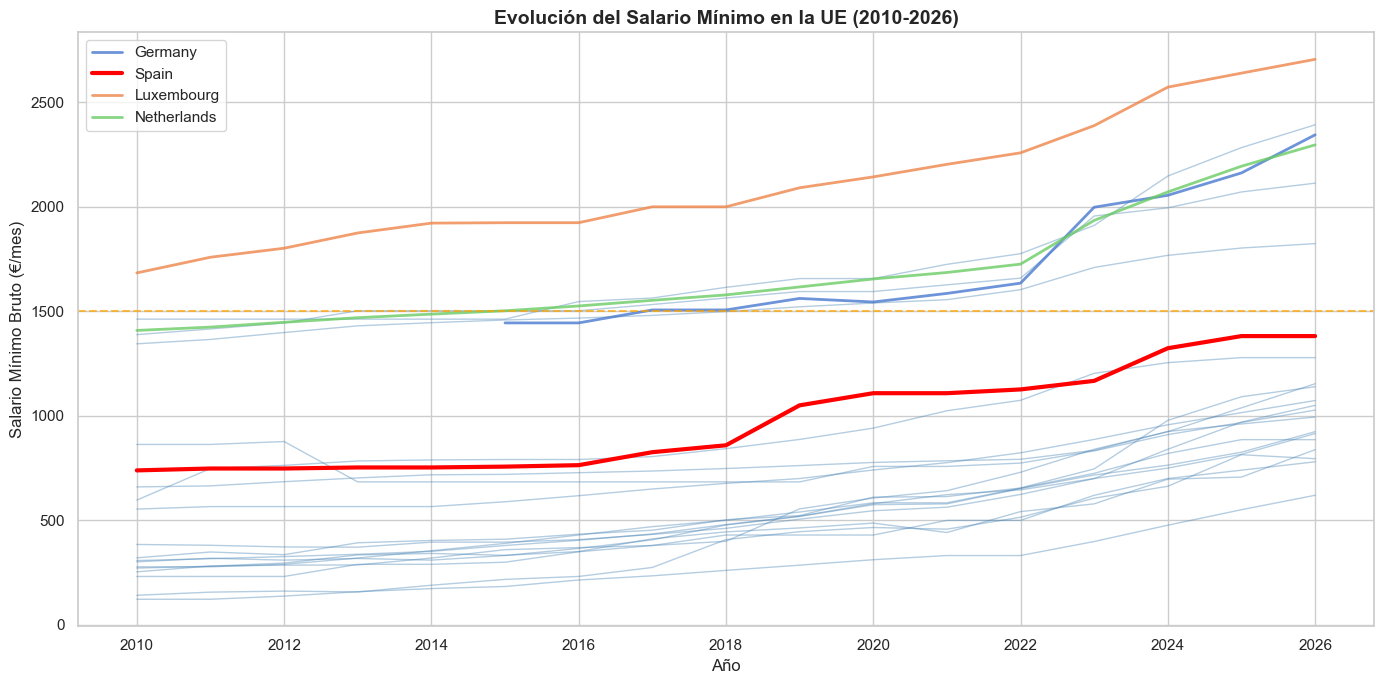

Fuente: Eurostat (earn_mw_cur)


In [12]:
# Filtramos solo los datos de S1 (primer semestre) para no duplicar años
# y solo países de la UE27 con datos desde 2010
paises_ue = [
    'Belgium', 'Bulgaria', 'Czechia', 'Germany', 'Estonia', 'Ireland',
    'Greece', 'Spain', 'France', 'Croatia', 'Latvia', 'Lithuania',
    'Luxembourg', 'Hungary', 'Malta', 'Netherlands', 'Poland',
    'Portugal', 'Romania', 'Slovenia', 'Slovakia'
]

df_plot = df_long[
    (df_long['semestre'] == 'S1') &
    (df_long['pais'].isin(paises_ue)) &
    (df_long['anio'] >= 2010)
]

# Creamos la gráfica de líneas
fig, ax = plt.subplots(figsize=(14, 7))

for pais in paises_ue:
    datos_pais = df_plot[df_plot['pais'] == pais]
    # Destacamos España en rojo para contexto
    if pais == 'Spain':
        ax.plot(datos_pais['anio'], datos_pais['salario_minimo_eur'],
                linewidth=3, color='red', label='Spain', zorder=5)
    elif pais in ['Luxembourg', 'Germany', 'Netherlands']:
        ax.plot(datos_pais['anio'], datos_pais['salario_minimo_eur'],
                linewidth=2, alpha=0.8, label=pais)
    else:
        ax.plot(datos_pais['anio'], datos_pais['salario_minimo_eur'],
                linewidth=1, alpha=0.4, color='steelblue')

ax.set_title('Evolución del Salario Mínimo en la UE (2010-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Salario Mínimo Bruto (€/mes)')
ax.legend(loc='upper left')
ax.axhline(y=1500, color='orange', linestyle='--', alpha=0.7, label='1.500€ (reivindicación Euskadi)')
plt.tight_layout()
plt.show()

print('Fuente: Eurostat (earn_mw_cur)')

---
## 5. PLAN DE ANÁLISIS

El EDA completo seguirá esta estructura:

1. **Limpieza de datos** — tratamiento de nulos, formatos, outliers
2. **Enriquecimiento** — merge con datasets de PIB, vivienda, género y pobreza
3. **Análisis univariante** — distribución del salario mínimo por país
4. **Análisis bivariante** — relaciones entre salario mínimo y las demás variables
5. **Análisis multivariante** — correlaciones, heatmaps, pairplots
6. **Contraste de hipótesis** — ¿se confirman nuestras 5 hipótesis?
7. **Conclusiones y plan de acción**

---
*Datos: Eurostat (ec.europa.eu/eurostat) | Proyecto EDA — Data Science Bootcamp 2026*